In [13]:
import pandas as pd
import numpy as np

In [2]:
def compute_ister_score(dataset_df, user_info_df):
    merged_df = pd.merge(dataset_df, user_info_df, left_on="user_id", right_on="user_id")
    item_attr_interactions_df = merged_df[["item_id", "attr"]]
    item_attr_dist = item_attr_interactions_df.groupby(["item_id", "attr"]).size()
    attr_dist = item_attr_interactions_df.groupby("attr").size()
    igi_score = item_attr_dist / attr_dist
    
    # compute i_ster score
    ister_scores = dict()
    for iid in dataset_df["item_id"].unique():
        if 0 not in igi_score.loc[iid] or 1 not in igi_score.loc[iid]:
            ister_scores[iid] = 0
        else:
            diff = igi_score.loc[iid][0] - igi_score.loc[iid][1]
            ister_scores[iid] = diff / max(igi_score.loc[iid][0], igi_score.loc[iid][1])
    
    return ister_scores

In [8]:
dataset_df = pd.read_csv("ambar/ambar.dataset.rating", sep="\t", header=None, names=["user_id", "item_id", "rating"])

users_df = pd.read_csv("ambar/ambar.userlist", sep="\t")
users_df.columns = ["user_id", "attr"]

ister_scores = compute_ister_score(dataset_df, users_df)
dataset_df["i_ster"] = dataset_df["item_id"].map(ister_scores)

uster_scores = dataset_df.groupby("user_id")["i_ster"].median()
users_df["u_ster"] = users_df["user_id"].map(uster_scores)

# user analysis

In [7]:
users_df.groupby("attr")["u_ster"].mean()

attr
0    0.053454
1   -0.031903
Name: u_ster, dtype: float64

attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

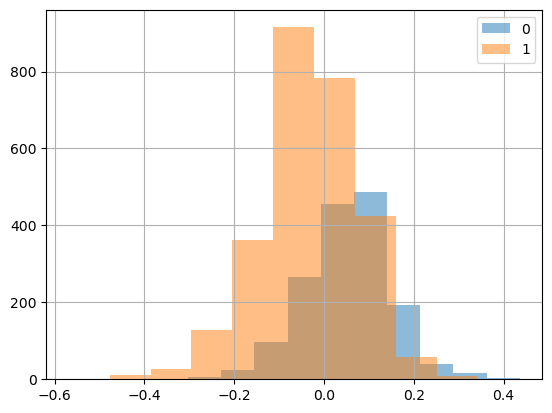

In [9]:
users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

In [10]:
users_df["attr"].value_counts() / len(users_df)

1    0.63103
0    0.36897
Name: attr, dtype: float64

In [11]:
df = dataset_df.merge(users_df, left_on="user_id", right_on="user_id")
print((df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).mean())
print((df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).mean())

0.5906142579584517
0.5408716829991805


## select only stereotypical users

0.7291011942174733
0.6148474825431827
0.6570037105751392
attr
0    0.097070
1   -0.096686
Name: u_ster, dtype: float64
1    0.59054
0    0.40946
Name: attr, dtype: float64
0.6525511836212412
0.6369497575242242


attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

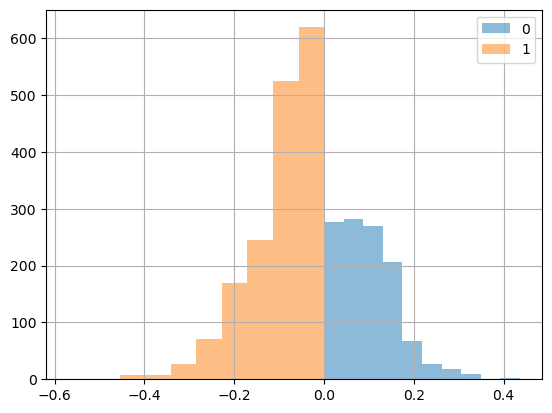

In [27]:
users0_df = users_df[(users_df["attr"] == 0) & (users_df["u_ster"] > 0)]
users1_df = users_df[(users_df["attr"] == 1) & (users_df["u_ster"] < 0)]

print(len(users0_df) / (users_df["attr"] == 0).sum())
print(len(users1_df) / (users_df["attr"] == 1).sum())

stereotypical_users_df = pd.concat([users0_df, users1_df])
print(len(stereotypical_users_df) / len(users_df))

print(stereotypical_users_df.groupby("attr")["u_ster"].mean())
print(stereotypical_users_df["attr"].value_counts() / len(stereotypical_users_df))

df = dataset_df.merge(stereotypical_users_df, left_on="user_id", right_on="user_id")
print((df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).mean())
print((df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).mean())

stereotypical_users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

# item analysis

In [28]:
items0 = dict()
items1 = dict()
for iid, score in ister_scores.items():
    if score > 0:
        items0[iid] = score
    elif score < 0:
        items1[iid] = score

print(len(items0) / len(ister_scores), len(items1) / len(ister_scores))
print(np.mean(list(items0.values())), np.mean(list(items1.values())))

0.48426445474505975 0.5157355452549403
0.24749578968301988 -0.2810776898268359
